# Course: Deep Learning
# Author: Sandro Camargo sandrocamargo@unipampa.edu.br
# MNIST Classification with ANN

Dataset: '/content/sample_data/' mnist

Dataset description: https://www.tensorflow.org/datasets/catalog/mnist

To open this code in your Google Colab environment, [click here](https://colab.research.google.com/github/Sandrocamargo/deep-learning/blob/master/dl_class05_mnist.ipynb).


Loading libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import layers, models, optimizers, losses, metrics
from sklearn.preprocessing import label_binarize
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

Defining image parameters

In [ ]:
np.random.seed(1)
image_size = 28 # width and length
no_of_different_labels = 10 #  i.e. 0, 1, 2, 3, ..., 9
image_pixels = image_size * image_size

Loading dataset from google colab

In [ ]:
data_path = "/content/sample_data/"
train_data = np.loadtxt(data_path + "mnist_train_small.csv", delimiter=",")
test_data = np.loadtxt(data_path + "mnist_test.csv", delimiter=",")

Scaling the inputs in [0,1] range and presenting the input and output dataset dimensions

In [ ]:
fac = 0.99 / 255
train_imgs = np.asarray(train_data[:, 1:]) * fac + 0.01
test_imgs = np.asarray(test_data[:, 1:]) * fac + 0.01

Transforming arrays into images

Splitting inputs and outputs
Binarizing outputs


In [ ]:
train_labels = np.asarray(train_data[:, :1])
test_labels = np.asarray(test_data[:, :1])
print('The training dataset (input) dimensions are: ', train_imgs.shape)
print('The training dataset (output) dimensions are: ', train_labels.shape)
print('The testing dataset (input) dimensions are: ', test_imgs.shape)
print('The testing dataset (output) dimensions are: ',test_labels.shape)

train_labels_bin = label_binarize(train_labels, classes=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
test_labels_bin = label_binarize(test_labels, classes=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

The training dataset (input) dimensions are:  (20000, 784)
The training dataset (output) dimensions are:  (20000, 1)
The testing dataset (input) dimensions are:  (10000, 784)
The testing dataset (output) dimensions are:  (10000, 1)


Inspecting the training set

Showing the first 20 samples and their labels

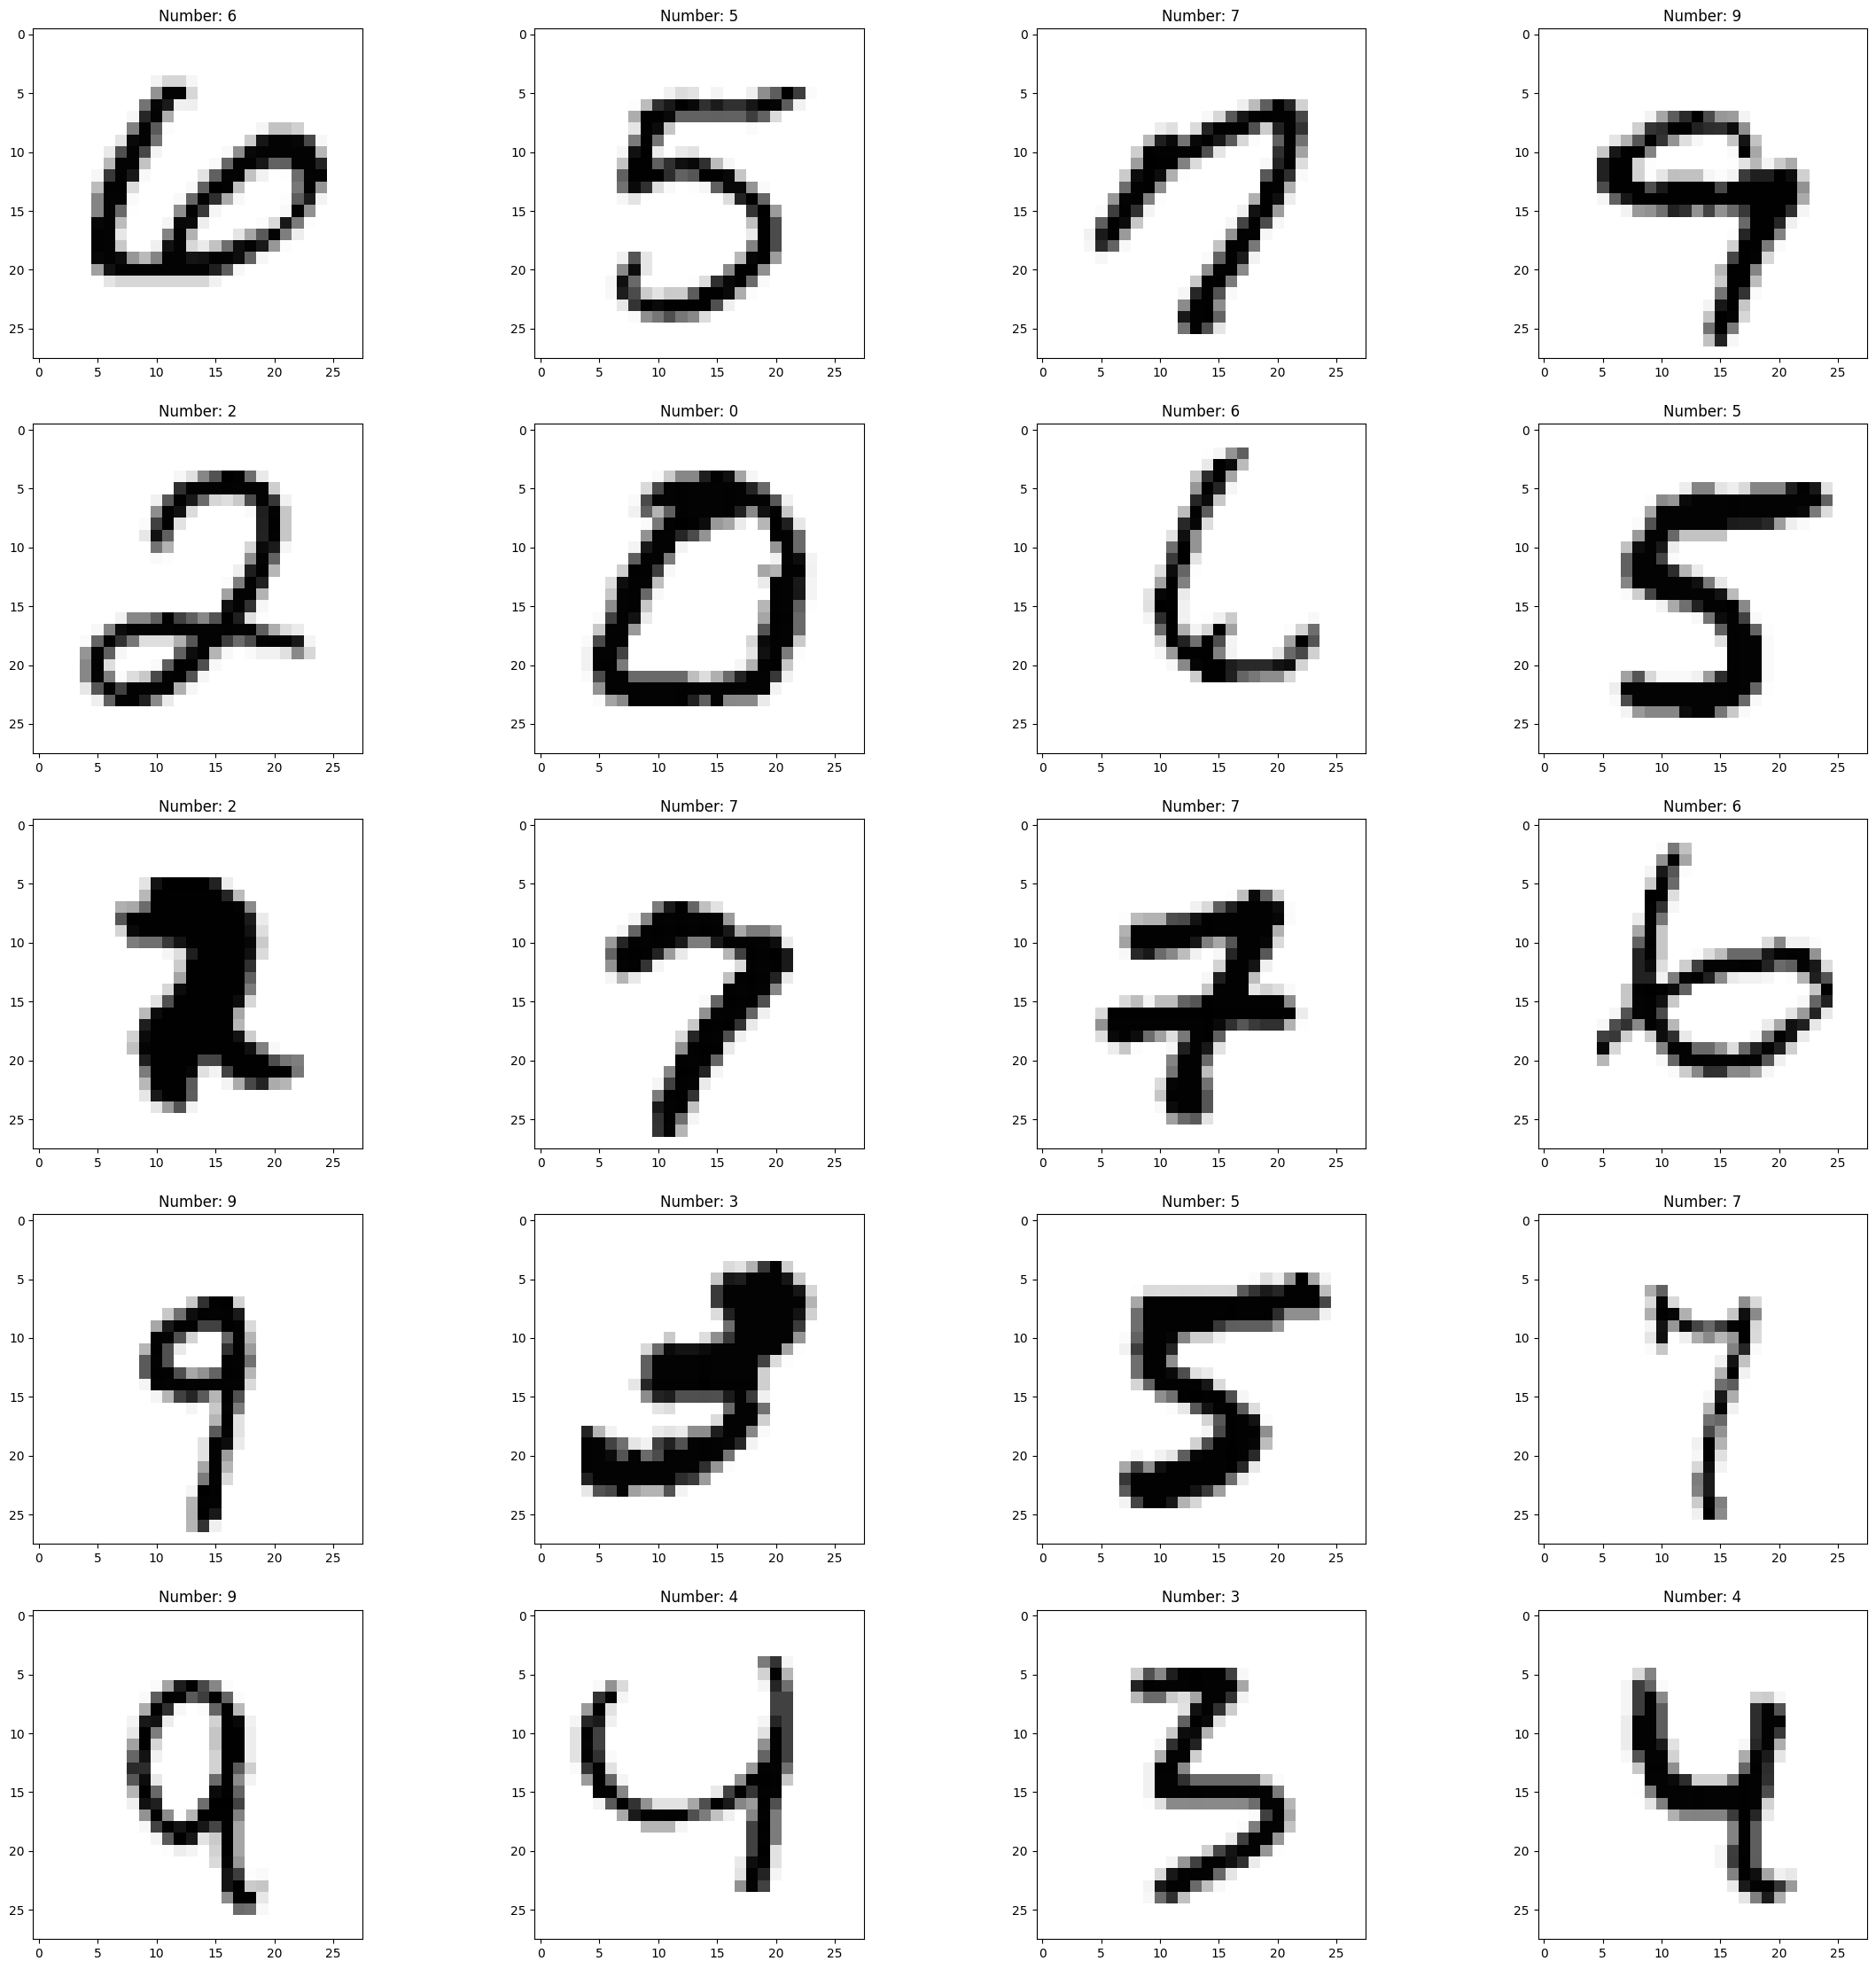

In [ ]:
fig, ax = plt.subplots(nrows=5, ncols=4, figsize=(image_size, image_size))

for i in range(5):
  for j in range(4):
    img = train_data[i*5+j,range(1,785)].reshape((image_size,image_size))
    ax[i,j].imshow(img, cmap="Greys")
    ax[i,j].title.set_text("Number: " + str(int(train_data[i*5+j,0])))
plt.show()

Creating and training the model


In [ ]:
model = models.Sequential([
  layers.Input(shape=[image_pixels]),
  layers.Dense(128, activation='relu'),
  layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer=optimizers.Adam(0.001),
    loss=losses.CategoricalCrossentropy(from_logits=False),
    metrics=[metrics.CategoricalAccuracy()],
)

model.summary()

history = model.fit(
    train_imgs, train_labels_bin,
    epochs=20, verbose=1,
    validation_split=0.2
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - categorical_accuracy: 0.8774 - loss: 0.4369 - val_categorical_accuracy: 0.9293 - val_loss: 0.2567
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - categorical_accuracy: 0.9379 - loss: 0.2100 - val_categorical_accuracy: 0.9445 - val_loss: 0.2002
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - categorical_accuracy: 0.9577 - loss: 0.1507 - val_categorical_accuracy: 0.9513 - val_loss: 0.1686
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - categorical_accuracy: 0.9678 - loss: 0.1156 - val_categorical_accuracy: 0.9548 - val_loss: 0.1530
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - categorical_accuracy: 0.9758 - loss: 0.0890 - val_categorical_accuracy: 0.9585 - val_loss: 0.1384
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - categorical_accuracy: 0.9821 - loss: 0.0687 - val_categorical_accuracy: 0.9575 - val_loss: 0.1420
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - categorical_accuracy: 0.9852 - los

Plotting the loss function on training and validation set.

The best value for epochs is when the validation loss starts to increase.

---



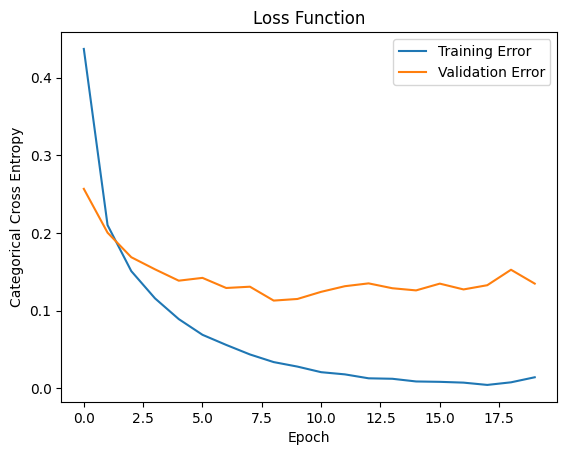

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss Function')
plt.ylabel('Categorical Cross Entropy')
plt.xlabel('Epoch')
plt.legend(['Training Error','Validation Error'], loc='upper right')
plt.savefig("trainingerror.pdf")
plt.show()

Plotting the classification accuracy on training and validation sets

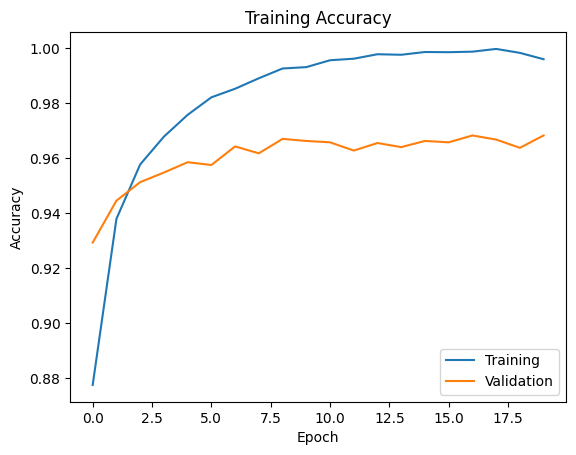

Training Accuracy: 0.996
Validation Accuracy: 0.9682


In [ ]:
plt.plot(history.history['categorical_accuracy'])
plt.plot(history.history['val_categorical_accuracy'])
plt.title('Training Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training','Validation'], loc='lower right')
plt.savefig("trainingaccuracy.pdf")
plt.show()
print("Training Accuracy:", round(history.history['categorical_accuracy'][-1],4))
print("Validation Accuracy:", round(history.history['val_categorical_accuracy'][-1],4))

Evaluates performance on test set
Presents the classification accuracy

In [ ]:
scores = model.evaluate(
    test_imgs, test_labels_bin, verbose=1
)

print("%s: %.2f%%" % (model.metrics_names[1], scores[1]*100))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - categorical_accuracy: 0.9673 - loss: 0.1477
compile_metrics: 96.73%


Summarizing the performance on training set


In [ ]:
test_predictions = model.predict(test_imgs)
print(confusion_matrix(test_predictions.argmax(axis=1), test_labels_bin.argmax(axis=1)))
print(classification_report(test_predictions.argmax(axis=1), test_labels_bin.argmax(axis=1), target_names=['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[[ 968    0    6    2    3    7    6    1    6    6]
 [   0 1120    2    2    0    0    3    3    1    4]
 [   0    6 1002    3    6    2    1   10    4    3]
 [   1    0    4  973    0    8    1    2    6    9]
 [   0    1    0    0  933    1    3    1    5    4]
 [   0    1    0    8    0  850    3    0    7    3]
 [   5    4    8    0    7   10  936    0    5    2]
 [   2    1    7    7    5    2    2  995    7    3]
 [   2    2    3   13    5    9    3    1  929    8]
 [   2    0    0    2   23    3    0   15    4  967]]
              precision    recall  f1-score   support

           0       0.99      0.96      0.98      1005
           1       0.99      0.99      0.99      1135
           2       0.97      0.97      0.97      1037
           3       0.96      0.97      0.97      1004
           4       0.95      0.98      0.97       948
           5       0.95      0.97      0.96       872
           6       0.98      0.96      0.97      

Confusion Matrix Heatmap

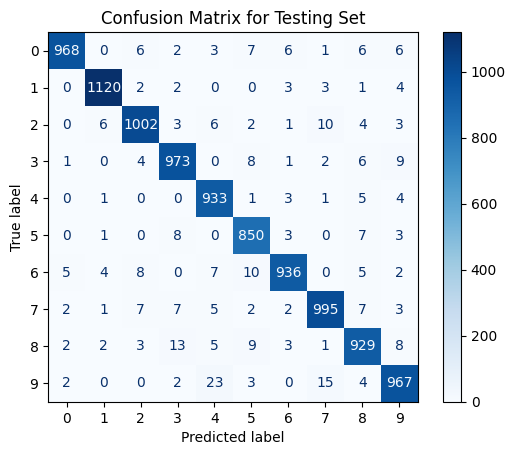

In [ ]:
cm = confusion_matrix(test_predictions.argmax(axis=1), test_labels_bin.argmax(axis=1))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'])
disp.plot(cmap="Blues")
plt.title('Confusion Matrix for Testing Set')
plt.savefig("confusionmatrix.pdf")
plt.show()

Reporting some misclassified samples

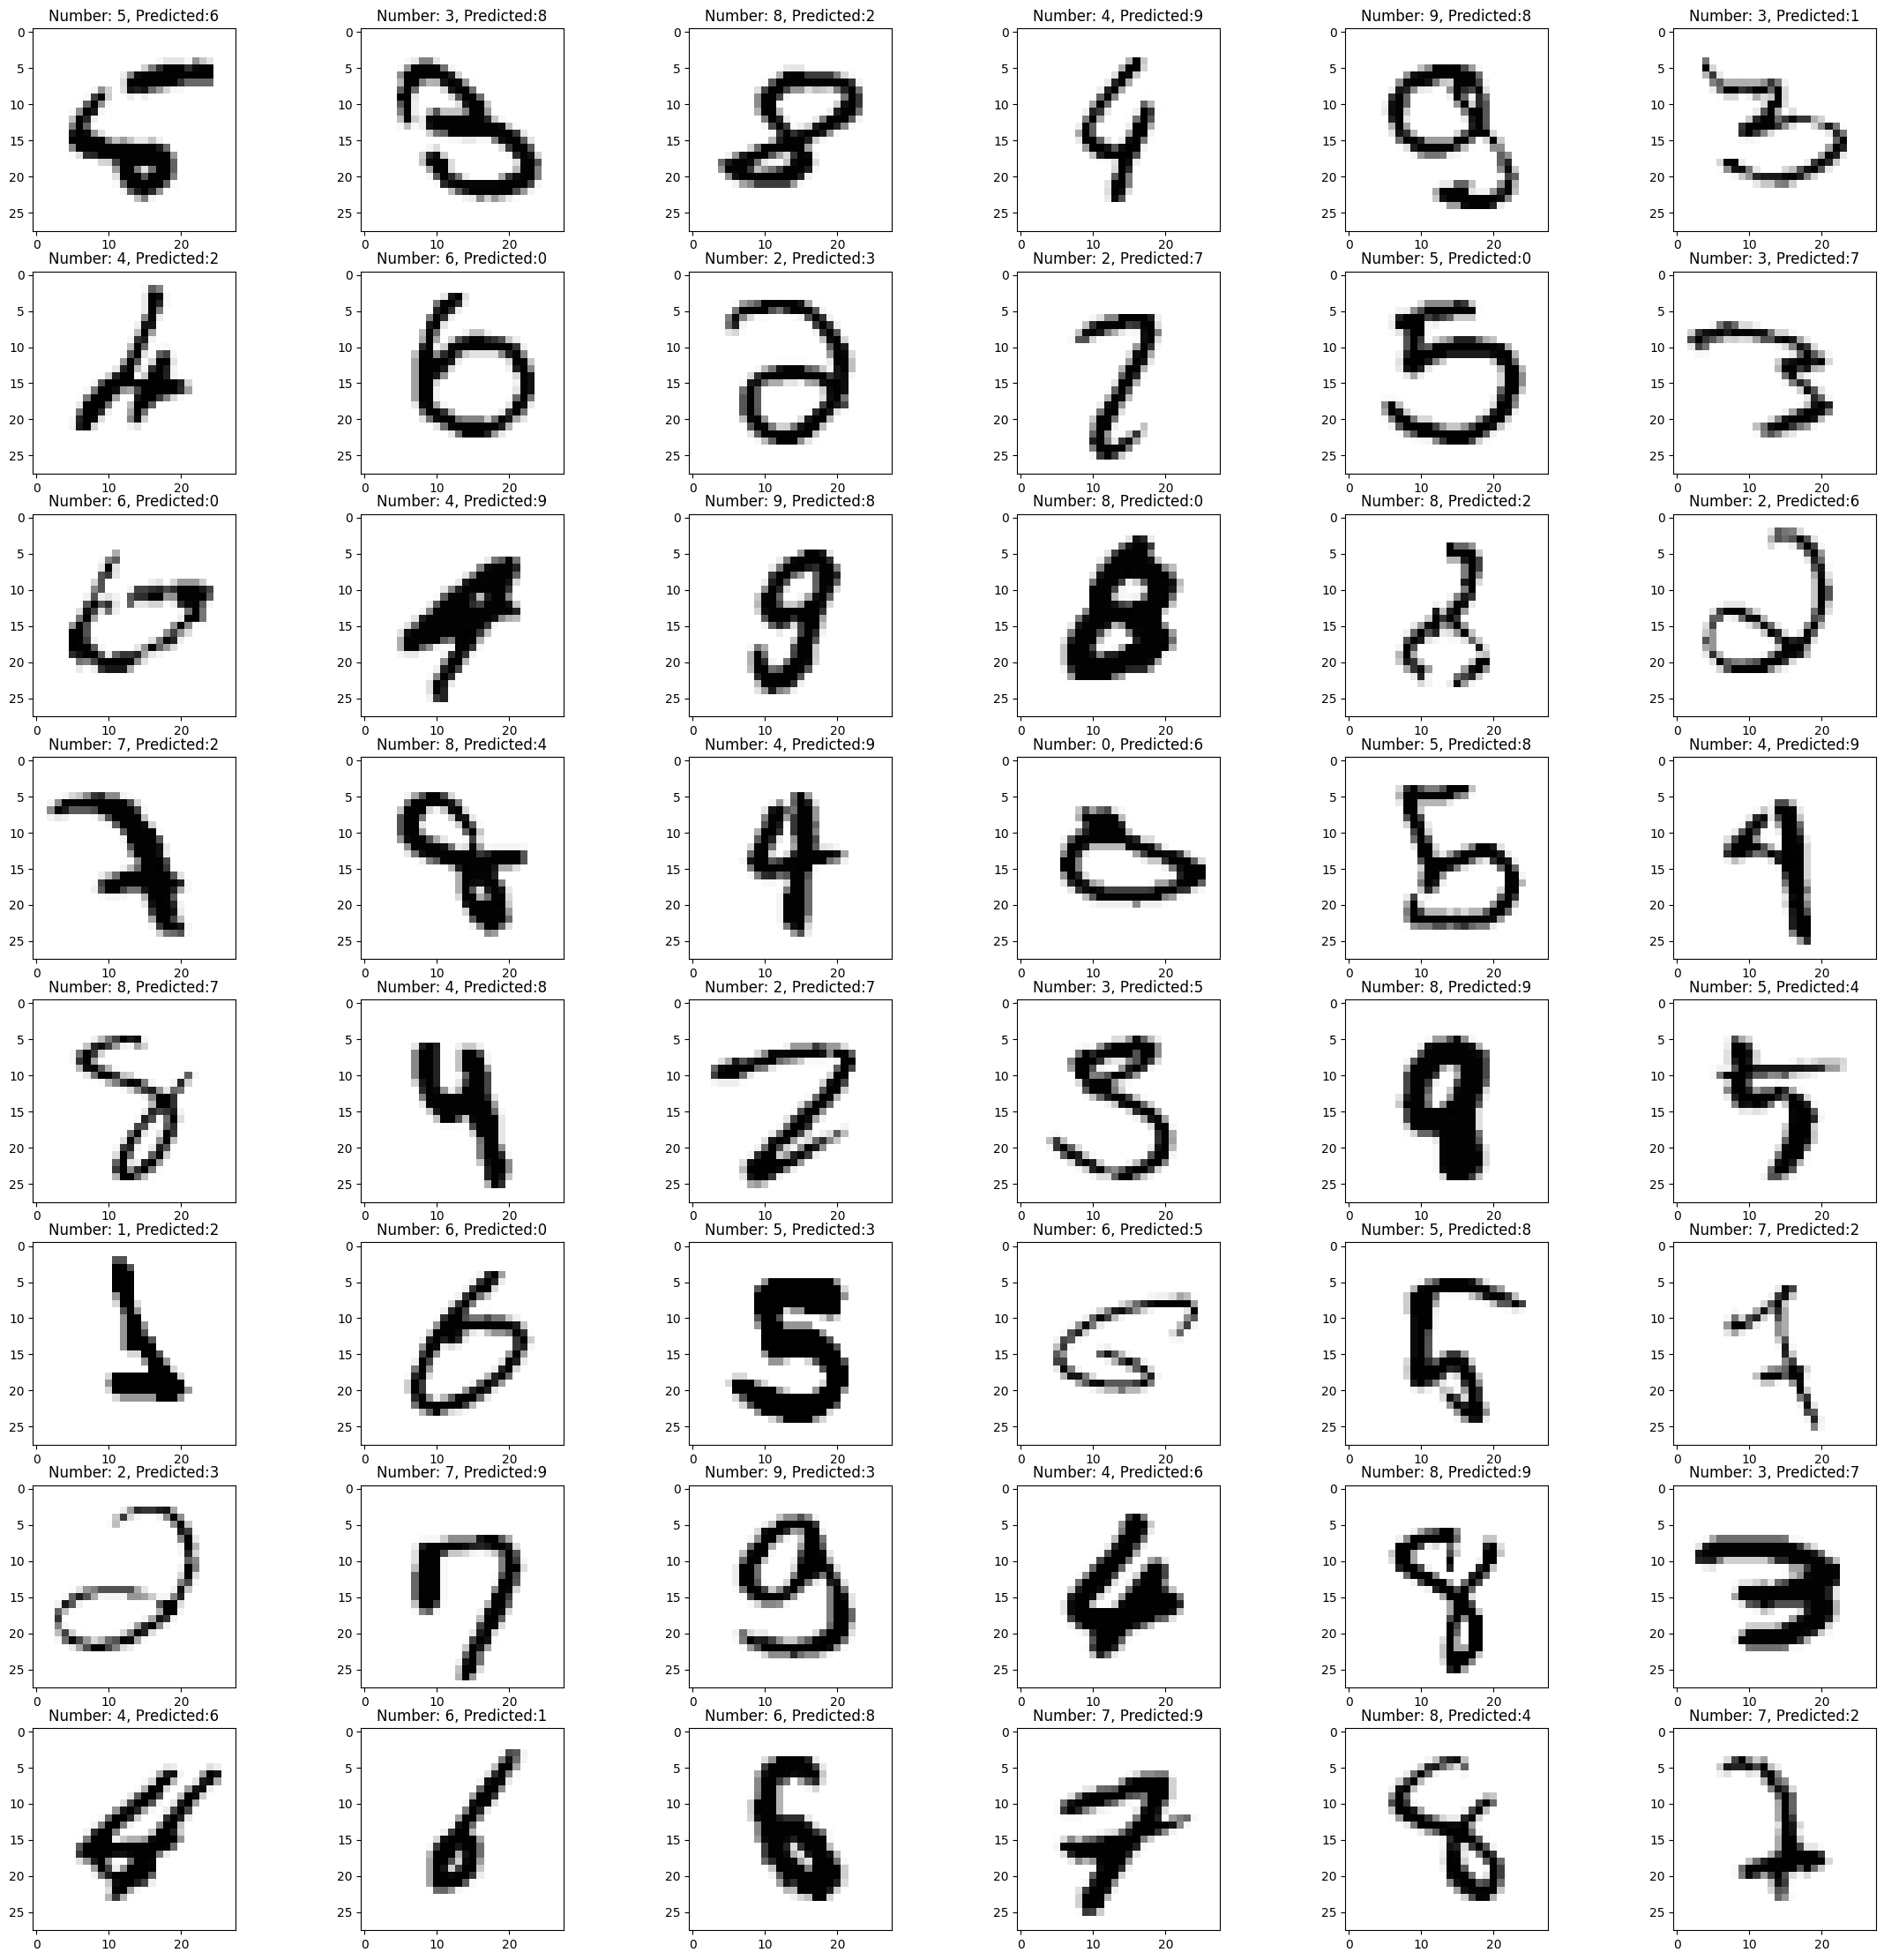

In [ ]:
i = 0
j = -1

fig, ax = plt.subplots(nrows=8, ncols=6, figsize=(image_size, image_size))

for k in range(5000):
  if test_predictions.argmax(axis=1)[k]!=test_labels_bin.argmax(axis=1)[k]:
      if i==8:
         break
      j = j + 1
      img = test_data[k,range(1,785)].reshape((image_size,image_size))
      ax[i,j].imshow(img, cmap="Greys")
      ax[i,j].title.set_text("Number: " + str(int(test_data[k,0])) + ", Predicted:" + str(test_predictions.argmax(axis=1)[k]))
      if j>4:
         j = -1
         i = i + 1
plt.show()

In [ ]:
i = 0
j = -1

for k in range(5000):
  if test_predictions.argmax(axis=1)[k]!=test_labels_bin.argmax(axis=1)[k]:
      print("Real:",test_labels[k],"Pred:",test_predictions.argmax(axis=1)[k],"Output:",test_predictions[k])

Real: [5.] Pred: 6 Output: [2.1143020e-08 1.6564654e-10 1.7778665e-07 9.2870268e-06 1.1850243e-10
 2.6823168e-03 9.9730575e-01 3.1979506e-09 2.4389790e-06 1.3196826e-10]
Real: [3.] Pred: 8 Output: [5.9544875e-10 5.2826535e-06 3.8311327e-06 4.4342902e-01 2.1686274e-08
 1.0511149e-04 6.0876832e-06 2.6031571e-06 5.5644745e-01 5.7642552e-07]
Real: [8.] Pred: 2 Output: [4.6856571e-06 7.6415041e-11 9.1077805e-01 7.7736792e-07 1.2487233e-09
 1.1874290e-09 1.0594272e-05 3.1086017e-07 8.9205496e-02 5.2029669e-08]
Real: [4.] Pred: 9 Output: [2.0906621e-06 3.7835311e-04 2.8640789e-06 7.8909754e-05 6.6690281e-02
 2.8293007e-07 1.7834801e-02 5.3351471e-07 3.8164508e-06 9.1500795e-01]
Real: [9.] Pred: 8 Output: [2.3241858e-04 1.8869968e-09 1.7849106e-02 6.6155167e-06 3.6100753e-10
 4.1496335e-07 6.4270957e-09 7.8687016e-08 9.7920448e-01 2.7068034e-03]
Real: [3.] Pred: 1 Output: [9.55730854e-08 8.85335505e-01 5.14206477e-07 1.11066766e-01
 8.59776992e-06 1.39067660e-03 1.90711929e-03 2.88729527e-04
 